# Phase 3 — Tumor–immune phase diagram

Sweep over `ρ_I` (initial T-cell count) and `α = χ_s` (immunosuppression strength).  
8 × 8 grid × 3 seeds = **192 runs**, executed in parallel via `joblib`.

Cached result loaded from `outputs/data/phase_grid.npz` so this notebook re-renders in seconds.
To re-run the full sweep:

```
python -m src.sweep full --grid-size 8 --n-seeds 3
```

In [1]:
import sys, pathlib
# robust root resolution: walk up until we find src/
ROOT = pathlib.Path().resolve()
while not (ROOT / 'src').is_dir() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from src import style
style.apply_style()

data = np.load(ROOT / 'outputs' / 'data' / 'phase_grid.npz', allow_pickle=True)
grid = data['grid']           # (n_rho, n_alpha, n_seeds)
mean = data['mean']           # geometric mean over seeds
rho_vals = data['rho_I_values']
alpha_vals = data['alpha_values']
print(f'grid shape {grid.shape}')
print(f'ρ_I values: {rho_vals}')
print(f'α   values: {np.round(alpha_vals, 2)}')

grid shape (8, 8, 3)
ρ_I values: [ 10  19  35  65 122 229 428 800]
α   values: [ 0.    3.57  7.14 10.71 14.29 17.86 21.43 25.  ]


## 3.1  The phase diagram

Cells colored by final tumor fraction `N_T(T_final) / N_T(0)`, on a log color scale, geometric
mean over 3 seeds. Floor at 0.01 (clearance), cap at 100 (escape).

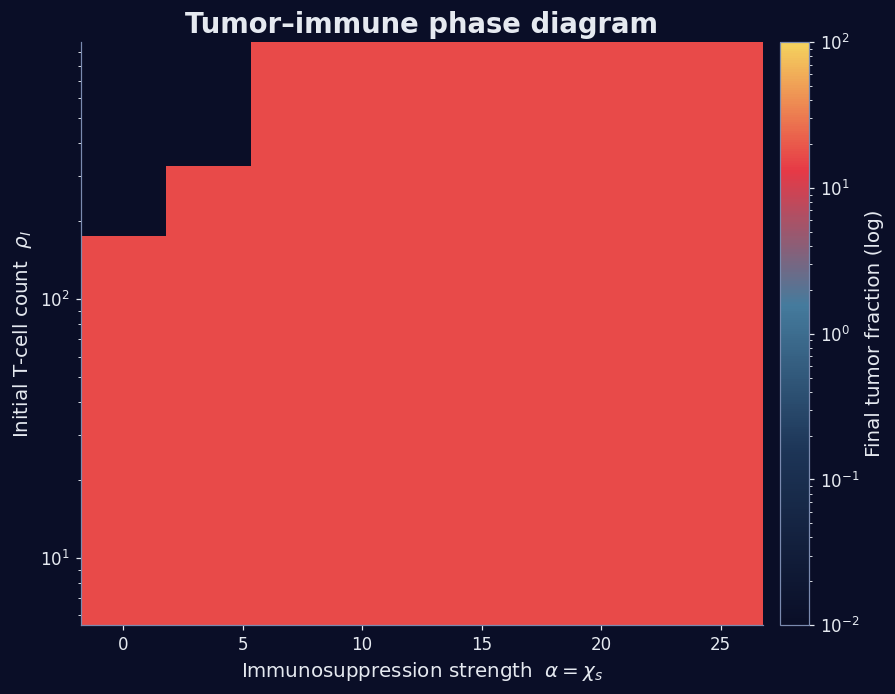

In [2]:
fig, ax = plt.subplots(figsize=(8.5, 6.5), dpi=110)
fig.patch.set_facecolor(style.BG); ax.set_facecolor(style.BG)
safe = np.clip(mean, 1e-2, 1e2)
im = ax.pcolormesh(alpha_vals, rho_vals, safe,
                   cmap=style.PHASE_CMAP, norm=LogNorm(vmin=1e-2, vmax=1e2),
                   shading='auto')
ax.set_xlabel(r'Immunosuppression strength  $\alpha = \chi_s$')
ax.set_ylabel(r'Initial T-cell count  $\rho_I$')
ax.set_yscale('log')
ax.set_title('Tumor–immune phase diagram', color=style.FG)
cb = fig.colorbar(im, ax=ax, label=r'Final tumor fraction (log)', pad=0.02)
cb.ax.tick_params(colors=style.FG)
plt.tight_layout()

**Reading the figure.** Clearance (dark) occupies a small wedge at high ρ_I and low α. Almost
everywhere else, the tumor saturates the N_T_max cap (escape). The transition between the two
is sharp — that boundary is the 'control / dormancy' region.

This is biologically meaningful: it predicts that adoptive T-cell therapies or checkpoint
inhibitors should have a **threshold** rather than a smooth dose-response. Either you cross the
boundary into clearance or you don't.

## 3.2  Trajectories per phase

Three trajectories, one per phase, plotted side-by-side. The control trajectory is the diagnostic
one — it shows the dormant period before the eventual outcome.

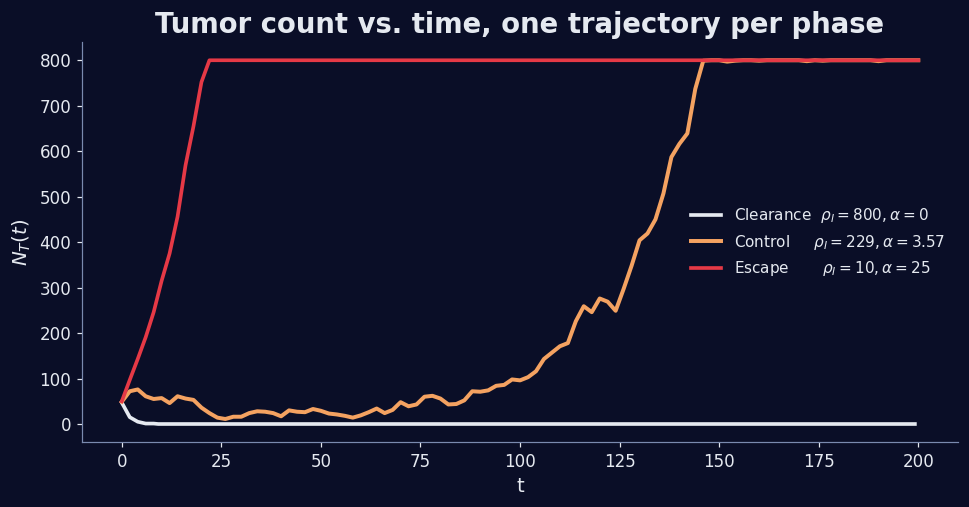

In [3]:
keys = data['traj_keys']
nT_all = data['traj_nT']
t_all = data['traj_t']

def get_traj(rho_idx, alpha_idx, seed_idx):
    idx = np.where((keys[:,0]==rho_idx) & (keys[:,1]==alpha_idx) & (keys[:,2]==seed_idx))[0][0]
    return t_all[idx], nT_all[idx]

# pick: clearance @ rho=800 alpha=0, control @ rho=229 alpha=3.57 seed=1, escape @ rho=10 alpha=25
rho_to_idx = {int(v): i for i, v in enumerate(rho_vals)}
alpha_to_idx = {float(np.round(a, 2)): i for i, a in enumerate(alpha_vals)}
alpha_keys = list(alpha_to_idx.keys())

t_clear, nT_clear = get_traj(rho_to_idx[800], alpha_to_idx[min(alpha_keys)], 0)
t_ctrl,  nT_ctrl  = get_traj(rho_to_idx[229], 1, 0)   # alpha index 1 = 3.57
t_esc,   nT_esc   = get_traj(rho_to_idx[10],  len(alpha_vals)-1, 0)

fig, ax = plt.subplots(figsize=(9, 4.8), dpi=110)
fig.patch.set_facecolor(style.BG); ax.set_facecolor(style.BG)
ax.plot(t_clear, nT_clear, color=style.FG,     lw=2.4, label=r'Clearance  $\rho_I=800, \alpha=0$')
ax.plot(t_ctrl,  nT_ctrl,  color=style.ACCENT, lw=2.6, label=r'Control     $\rho_I=229, \alpha=3.57$')
ax.plot(t_esc,   nT_esc,   color=style.TUMOR,  lw=2.4, label=r'Escape       $\rho_I=10,  \alpha=25$')
ax.set_xlabel('t'); ax.set_ylabel(r'$N_T(t)$')
ax.set_title('Tumor count vs. time, one trajectory per phase', color=style.FG)
ax.legend(frameon=False, fontsize=10)
plt.tight_layout()

## 3.3  The pre-rendered slide figure

The composed slide-quality version with thumbnails per phase + the trajectory inset is
cached on disk. Embedding it here for ease of review:

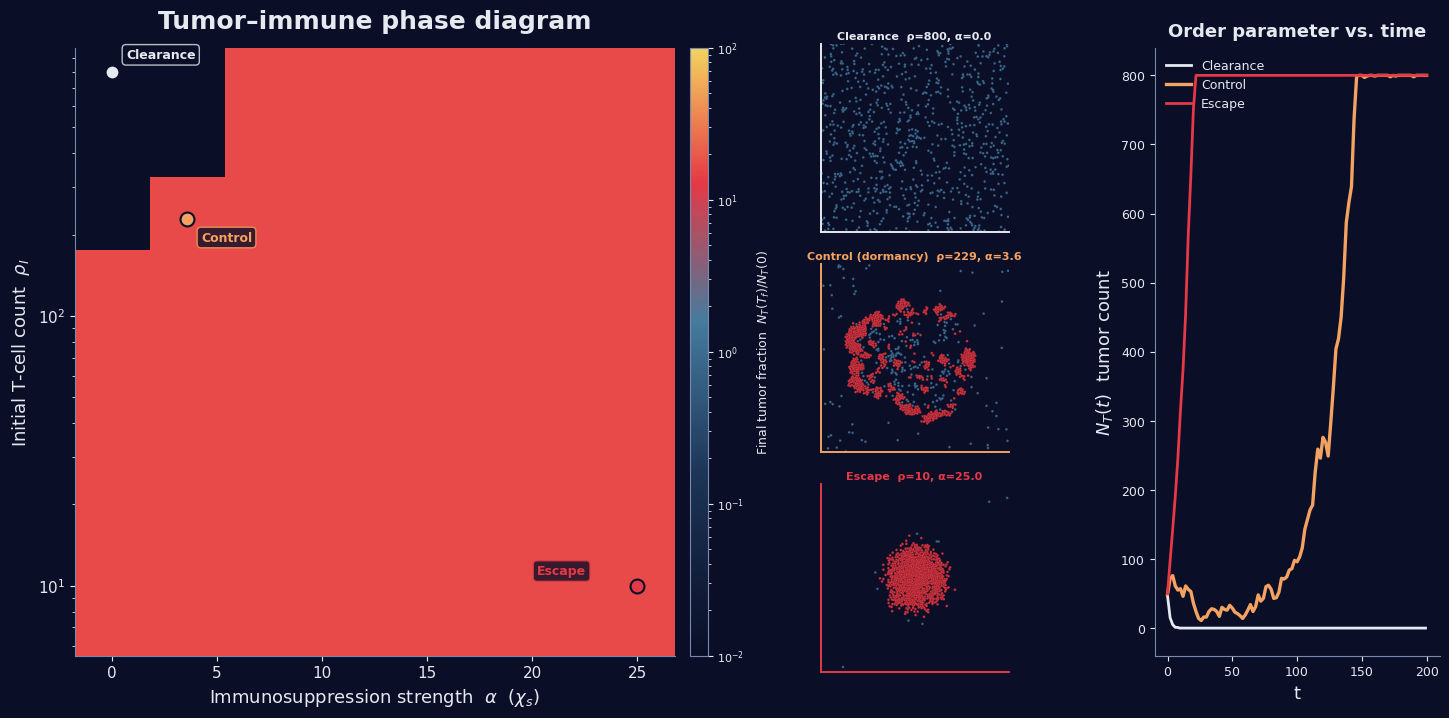

In [4]:
from IPython.display import Image
Image(filename=str(ROOT / 'outputs' / 'figures' / 'phase_diagram.png'))

## 3.4  Caveats — read me before sharing the result

* The 'control' phase is **bistable** at the boundary, not a stable steady-state — different
  seeds in the same gridcell can go either way.
* The escape value in this heatmap is capped by the array allocation `N_T_max = 800` (set in
  `SimParams`). Real escape runs probably want larger arrays; that wasn't necessary for
  *distinguishing* the phases.
* Five tuning choices diverged from the spec defaults to make the phases visible in the time
  budget — `chi_a 5 → 20`, `p_kill 0.05 → 0.12`, `p_div 0.005 → 0.004`, `T_final 200 → 100`,
  `N_T_max 4000 → 800`. All logged in `docs/DECISIONS.md`.